In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv('uber.csv')

# Drop unnecessary columns
data = data.drop(columns=['Unnamed: 0', 'key'])

# Check for null values and drop rows with any null values
data = data.dropna()

# Drop duplicate rows, if any
data = data.drop_duplicates()


# Filter out rows with invalid latitude and longitude values
data = data[(data.pickup_latitude < 90) & (data.dropoff_latitude < 90) &
            (data.pickup_latitude > -90) & (data.dropoff_latitude > -90) &
            (data.pickup_longitude < 180) & (data.dropoff_longitude < 180) &
            (data.pickup_longitude > -180) & (data.dropoff_longitude > -180)]

data.head() 

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [2]:
import numpy as np
from geopy.distance import distance

# Step 1: Convert 'pickup_datetime' to datetime format and extract time-based features
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], errors='coerce')
data['pickup_hour'] = data['pickup_datetime'].dt.hour
data['pickup_day'] = data['pickup_datetime'].dt.day
data['pickup_month'] = data['pickup_datetime'].dt.month
data['pickup_dayofweek'] = data['pickup_datetime'].dt.dayofweek

# step 2:
# Calculate distance using geopy
data['distance_km'] = [
    round(distance((data.pickup_latitude[i], data.pickup_longitude[i]),
                   (data.dropoff_latitude[i], data.dropoff_longitude[i])).km, 2)
    for i in data.index
]

# Step 3: Prepare the data for regression
# Drop columns we no longer need
data = data.drop(columns=['pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'])

In [3]:
data

,fare_amount,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,distance_km
0,7.5,1,19,7,5,3,1.68
1,7.7,1,20,17,7,4,2.45
2,12.9,1,21,24,8,0,5.04
3,5.3,3,8,26,6,4,1.66
4,16.0,5,17,28,8,3,4.48
...,...,...,...,...,...,...,...
199995,3.0,1,10,28,10,6,0.11
199996,7.5,1,1,14,3,4,1.88
199997,30.9,2,0,29,6,0,12.87
199998,14.5,1,14,20,5,2,3.54


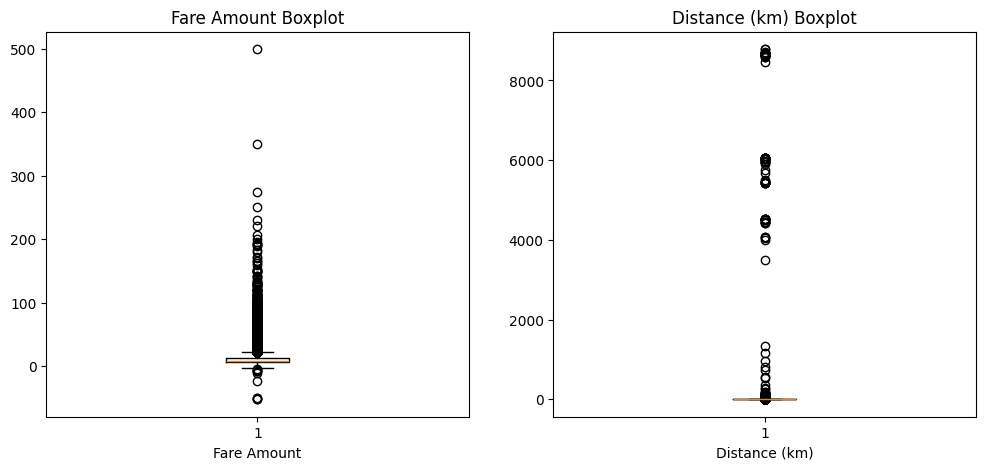

In [249]:
import matplotlib.pyplot as plt

# Step 1: Visualize Outliers Using Boxplots
plt.figure(figsize=(12, 5))

# Boxplot for 'fare_amount'
plt.subplot(1, 2, 1)
plt.boxplot(data['fare_amount'])
plt.title('Fare Amount Boxplot')
plt.xlabel('Fare Amount')

# Boxplot for 'distance_km'
plt.subplot(1, 2, 2)
plt.boxplot(data['distance_km'])
plt.title('Distance (km) Boxplot')
plt.xlabel('Distance (km)')

plt.show()

In [239]:
# # Filter based on suggested thresholds
data = data[(data['fare_amount'] > 0) & (data['fare_amount'] <= 150)]
data = data[(data['distance_km'] > 0) & (data['distance_km'] <= 40)]

In [240]:
data

,fare_amount,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,distance_km
0,7.5,1,19,7,5,3,1.68
1,7.7,1,20,17,7,4,2.45
2,12.9,1,21,24,8,0,5.04
3,5.3,3,8,26,6,4,1.66
4,16.0,5,17,28,8,3,4.48
...,...,...,...,...,...,...,...
199995,3.0,1,10,28,10,6,0.11
199996,7.5,1,1,14,3,4,1.88
199997,30.9,2,0,29,6,0,12.87
199998,14.5,1,14,20,5,2,3.54


In [250]:
# List of columns to analyze
columns_to_analyze = ['pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek']

# Calculate unique values, minimum, and maximum for specified columns
summary_stats = {
    'Column': [],
    'Unique Values': [],
    'Min Value': [],
    'Max Value': []
}

for column in columns_to_analyze:
    summary_stats['Column'].append(column)
    summary_stats['Unique Values'].append(data[column].nunique())
    summary_stats['Min Value'].append(data[column].min())
    summary_stats['Max Value'].append(data[column].max())

# Convert to DataFrame for display
summary_stats_df = pd.DataFrame(summary_stats)
print(summary_stats_df)

             Column  Unique Values  Min Value  Max Value
0       pickup_hour             24          0         23
1        pickup_day             31          1         31
2      pickup_month             12          1         12
3  pickup_dayofweek              7          0          6


In [251]:
import pandas as pd

# Calculate the correlation between fare_amount and distance_km
correlation = data[['fare_amount', 'distance_km', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'passenger_count']].corr()

print("Correlation:")
print(correlation)


Correlation:
                  fare_amount  distance_km  pickup_hour  pickup_day  \
fare_amount          1.000000     0.024726    -0.021485    0.001406   
distance_km          0.024726     1.000000    -0.000149   -0.001963   
pickup_hour         -0.021485    -0.000149     1.000000    0.004673   
pickup_day           0.001406    -0.001963     0.004673    1.000000   
pickup_month         0.023794    -0.000830    -0.003940   -0.017339   
pickup_dayofweek     0.007498    -0.005074    -0.086946    0.005617   
passenger_count      0.010167    -0.001622     0.013175    0.003228   

                  pickup_month  pickup_dayofweek  passenger_count  
fare_amount           0.023794          0.007498         0.010167  
distance_km          -0.000830         -0.005074        -0.001622  
pickup_hour          -0.003940         -0.086946         0.013175  
pickup_day           -0.017339          0.005617         0.003228  
pickup_month          1.000000         -0.008789         0.009790  
pickup_day

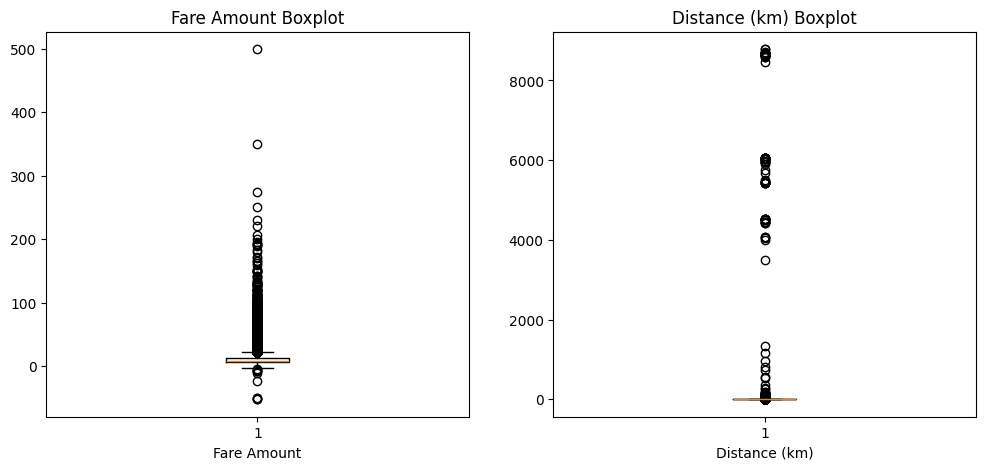

In [252]:
# Step 1: Visualize Outliers Using Boxplots
plt.figure(figsize=(12, 5))

# Boxplot for 'fare_amount'
plt.subplot(1, 2, 1)
plt.boxplot(data['fare_amount'])
plt.title('Fare Amount Boxplot')
plt.xlabel('Fare Amount')

# Boxplot for 'distance_km'
plt.subplot(1, 2, 2)
plt.boxplot(data['distance_km'])
plt.title('Distance (km) Boxplot')
plt.xlabel('Distance (km)')

plt.show()

In [244]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features and target variable
X = data[['distance_km', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'passenger_count']]
y = data['fare_amount']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)


Model Coefficients: [ 2.34849816e+00  1.13825807e-02 -3.68887164e-04  3.60996066e-02
 -4.54486574e-02  4.62531499e-02]
Intercept: 3.121844600322099
Mean Absolute Error (MAE): 2.2869593022945254
Root Mean Squared Error (RMSE): 4.210016465033155
R-squared (R²): 0.79746124103053


In [245]:
from sklearn.metrics import r2_score

# Calculate predictions on the training data
y_train_pred = model.predict(X_train)

# Calculate train and test R-squared (R²) scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R-squared (R²):", train_r2)
print("Testing R-squared (R²):", test_r2)


Training R-squared (R²): 0.795525867824732
Testing R-squared (R²): 0.79746124103053
